--- INITIATING: 03 EXPLAINABLE AI (SHAP) ---

⏳ Please upload your TRAINING Dataset CSV...


Saving Full detail-Full_Detail.csv to Full detail-Full_Detail.csv
⚡ Training Champion XGBoost Model...
🔍 Calculating SHAP values to reverse-engineer model logic...

--- Generating Global Feature Importance ---


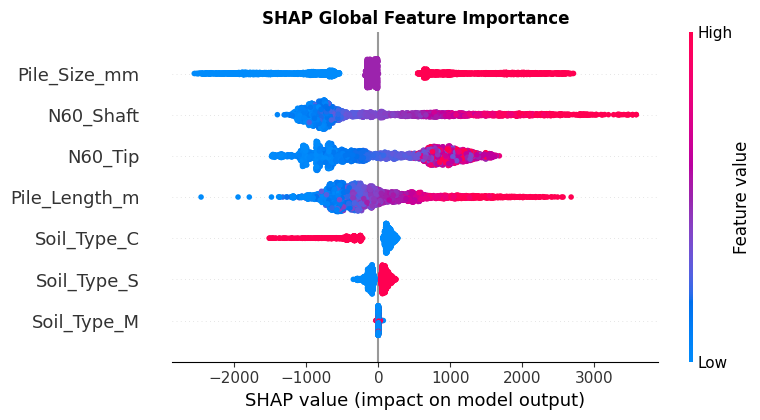


--- Generating 2D Geotechnical Interaction Plot ---


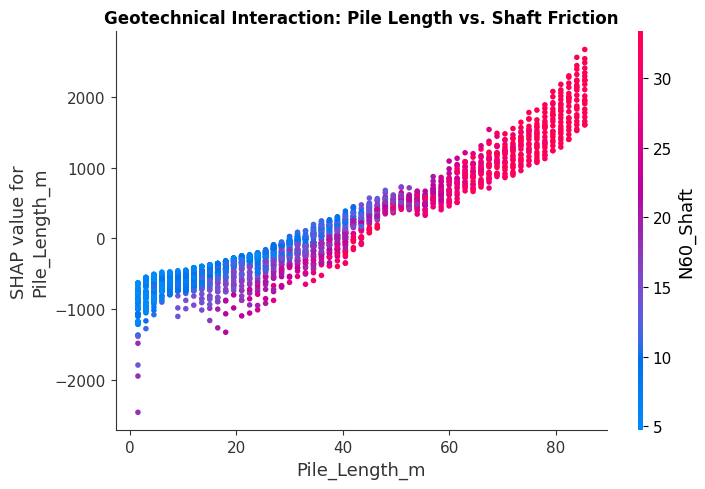


✅ XAI ANALYSIS COMPLETE.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

# Install SHAP if not already in the environment
!pip install shap -q
import shap

print("--- INITIATING: 03 EXPLAINABLE AI (SHAP) ---\n")

# ==========================================
# 1. DIRECT FILE UPLOAD (Only Training Data Needed for SHAP)
# ==========================================
try:
    from google.colab import files
    import io
    print("⏳ Please upload your TRAINING Dataset CSV...")
    uploaded_train = files.upload()
    train_filename = list(uploaded_train.keys())[0]
    df_train = pd.read_csv(io.BytesIO(uploaded_train[train_filename]))
except ImportError:
    train_filename = input("Enter TRAINING CSV file: ")
    df_train = pd.read_csv(train_filename)

df_train.columns = df_train.columns.str.strip()
df_train_encoded = pd.get_dummies(df_train, columns=['Soil_Type'], dtype=int)

feature_cols = ['Pile_Length_m', 'Pile_Size_mm', 'N60_Shaft', 'N60_Tip']
soil_cols = [col for col in df_train_encoded.columns if 'Soil_Type_' in col]
X_cols = feature_cols + soil_cols

X_train = df_train_encoded[X_cols]
y_train = df_train_encoded['Q_gross_kN']

# ==========================================
# 2. TRAIN CHAMPION MODEL
# ==========================================
print("⚡ Training Champion XGBoost Model...")
xgb_model = XGBRegressor(n_estimators=1000, learning_rate=0.05, max_depth=5, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)

# ==========================================
# 3. SHAP ANALYSIS
# ==========================================
print("🔍 Calculating SHAP values to reverse-engineer model logic...")
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_train)

print("\n--- Generating Global Feature Importance ---")
plt.title("SHAP Global Feature Importance", fontweight='bold')
shap.summary_plot(shap_values, X_train, show=False)
plt.tight_layout()
plt.show()

print("\n--- Generating 2D Geotechnical Interaction Plot ---")
shap.dependence_plot("Pile_Length_m", shap_values, X_train, interaction_index="N60_Shaft", show=False)
plt.title("Geotechnical Interaction: Pile Length vs. Shaft Friction", fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✅ XAI ANALYSIS COMPLETE.")